In [36]:
# Import libraries
import numpy as np
import pickle
import mne
import os
import ipywidgets as widgets
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
# set size of raw browser
mne.utils.config.set_config('MNE_BROWSE_RAW_SIZE','16.0,8.0')

In [37]:
BAD_CHANNELS = ["Iz", "FC4"]

def preprocess_data(path):
    raw = mne.io.read_raw_bdf(path, preload=True)
    events = mne.find_events(raw, stim_channel='Status', mask=65280, mask_type='not_and')
   
    sfreq = raw.info['sfreq']
    t_split = events[events[:, 2] == 31][0][0] / sfreq
    raw_sound = raw.copy().crop(tmax=t_split)
    raw_task = raw.copy().crop(tmin=t_split)


    raw_sound.set_montage('biosemi64')
    raw_task.set_montage('biosemi64')

  
    raw_sound.info['bads'] = BAD_CHANNELS
    raw_sound = raw_sound.copy().interpolate_bads(reset_bads=True)
    raw_task.info['bads'] = BAD_CHANNELS
    raw_task = raw_task.copy().interpolate_bads(reset_bads=True)


    raw_sound.resample(300)
    raw_task.resample(300)

    return raw_sound, raw_task


raw_s1, raw_t1 = preprocess_data("electrode_data/VJJ_1.bdf")
raw_s2, raw_t2 = preprocess_data("electrode_data/VJJ_2.bdf")




In [38]:
from mne.preprocessing import annotate_muscle_zscore

def clean_data(d0):

    # automaticcaly remoce muscle artifacts
    annot_muscle, _ = annotate_muscle_zscore(
        d0, ch_type="eeg", threshold=5, min_length_good=0.2, filter_freq=[110, 140]
    )
    
    d0.set_annotations(d0.annotations + annot_muscle)

    d1 = d0.copy().notch_filter(freqs=50)
    d1.filter(l_freq=1, h_freq=40)


    return d1

almost_clean_s1 = clean_data(raw_s1)
almost_clean_s2 = clean_data(raw_s2)


## Kig manuelt på ICA og fjern passende kompnenter


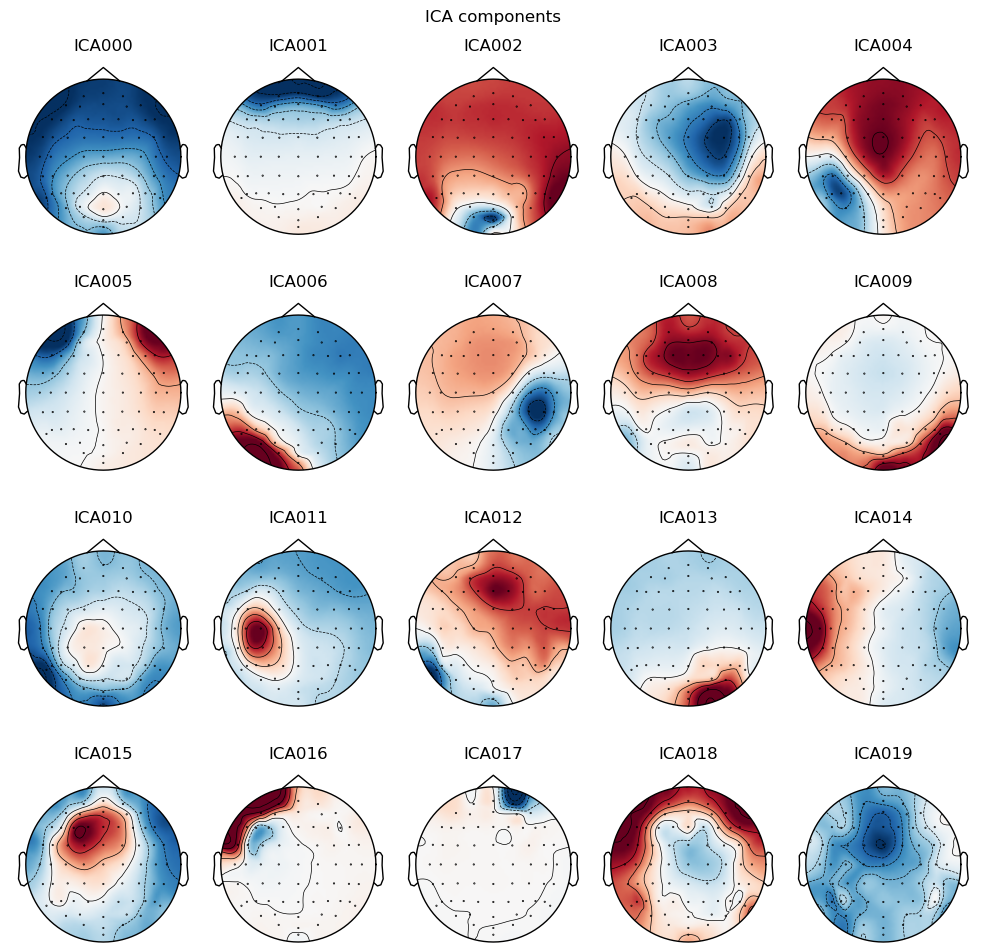

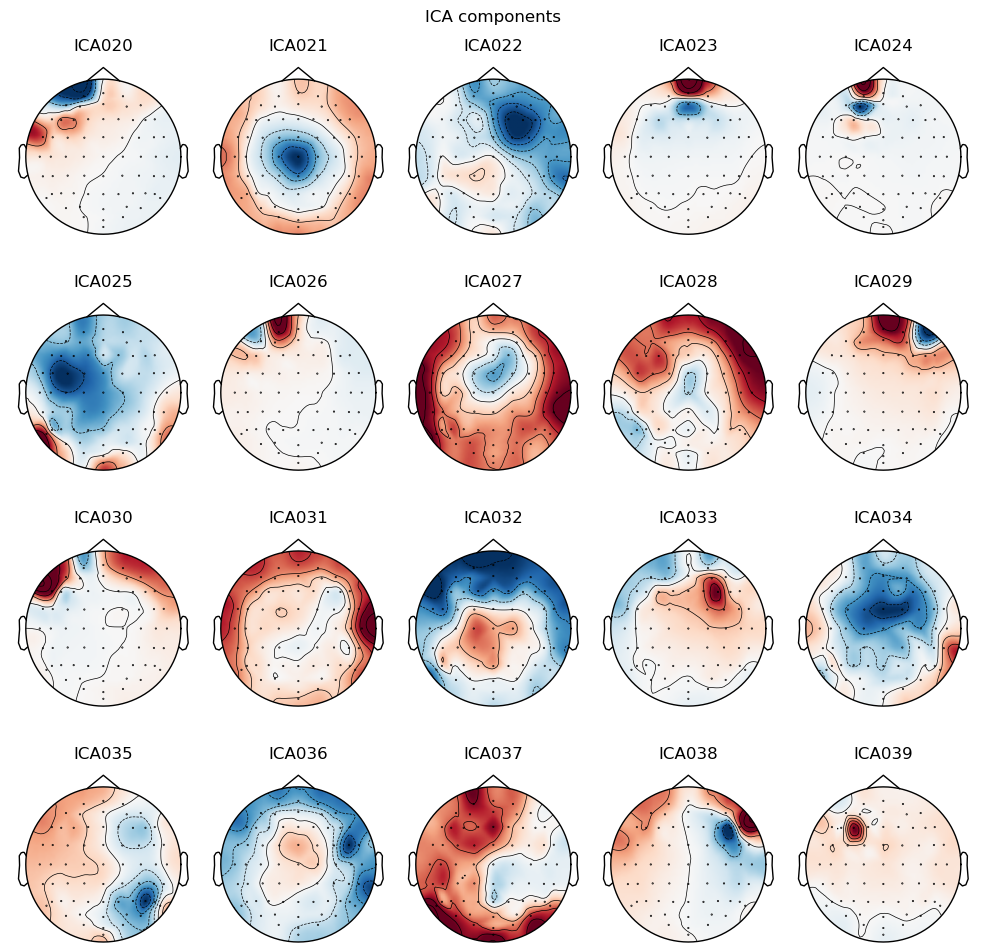

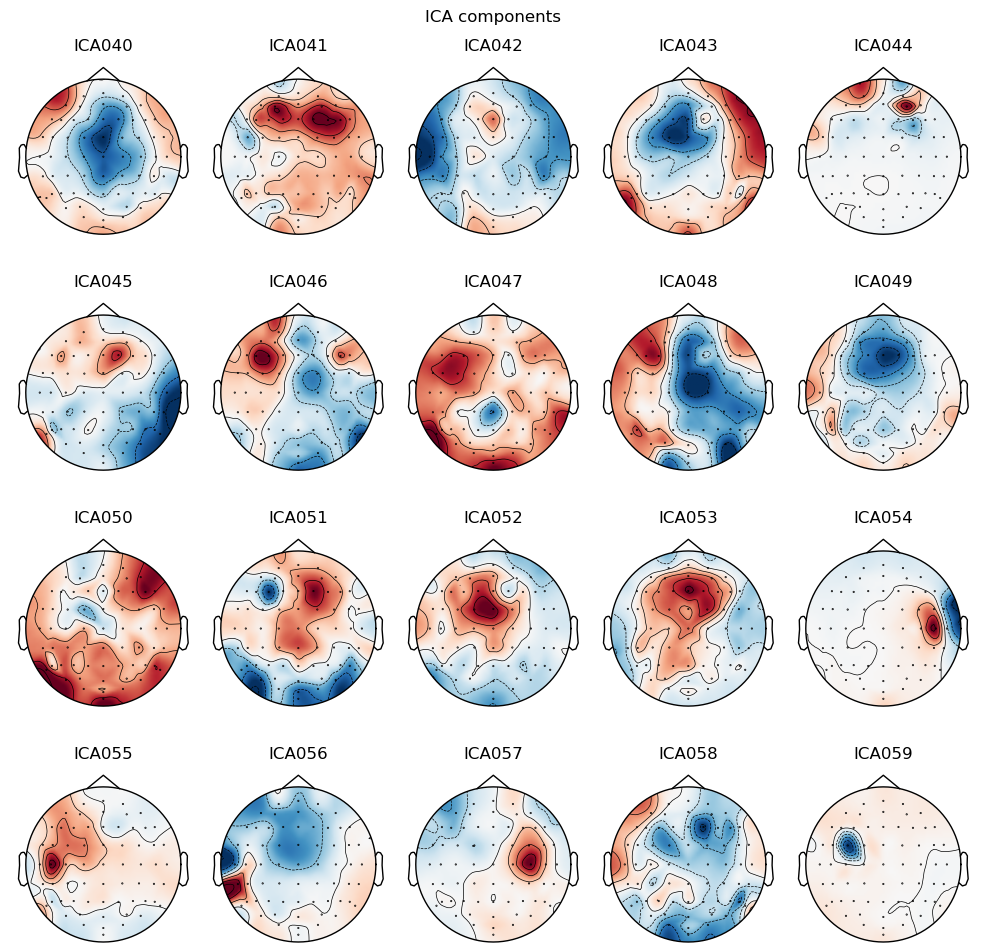

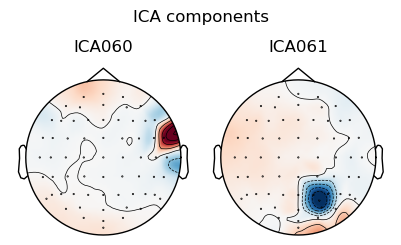

[<MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 975x967 with 20 Axes>,
 <MNEFigure size 390x260.5 with 2 Axes>]

In [40]:
# maniaally look at ica and exclude bad componetns
ica = mne.preprocessing.ICA()
ica.fit(almost_clean_s2.copy().pick('eeg'))
ica.plot_components()



In [41]:
d_s1 = ica.apply(almost_clean_s1.copy(),exclude=[0,1,3,7])
d_s2 = ica.apply(almost_clean_s2.copy(),exclude=[1,5])

In [42]:
def power_analysis(d):
    psd_obj = d.compute_psd(method='welch', fmin=1, fmax=40, n_fft=1024)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    idx_20hz = np.argmin(np.abs(freqs - 20))

    # Average power across all EEG channels at exactly 20 Hz
    mean_power_20hz = psds.mean(axis=0)[idx_20hz]

    # psd_obj.plot_topomap(ch_type='eeg', bands={'20Hz': (19, 21)})

    return psd_obj, mean_power_20hz


obj1, power1 = power_analysis(d_s1)
obj2, power2 = power_analysis(d_s2)


In [43]:

print(power1, power2)
print(power2 - power1)

7.74954660805315e-13 1.1673533657865637e-12
3.923987049812486e-13


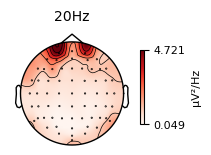

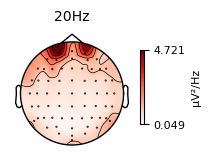

In [44]:
obj1.plot_topomap(ch_type='eeg', bands={'20Hz': (19, 21)})

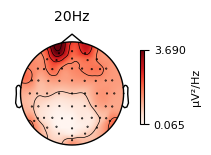

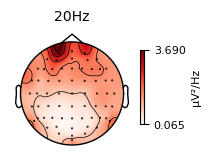

In [45]:
obj2.plot_topomap(ch_type='eeg', bands={'20Hz': (19, 21)})

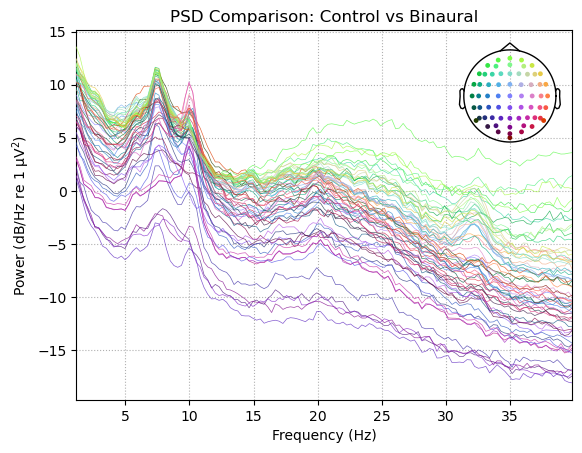

In [46]:
import matplotlib.pyplot as plt

# Plot the PSD for both conditions
fig, ax = plt.subplots()
# obj1.plot(axes=ax, show=False, spatial_colors=True) # Control
obj2.plot(axes=ax, show=False, spatial_colors=True) # Binaural
ax.set_title("PSD Comparison: Control vs Binaural")
plt.show()

In [47]:
import warnings
import mne

# 1. Mute Python's UserWarnings (hides the "nperseg > input length" text)
warnings.filterwarnings('ignore')

# 2. Mute MNE's informational logs (hides the "Setting X samples to NaN" text)
mne.set_log_level('WARNING')

In [48]:

def power_analysis_comprehensive(d):
    # 1. Compute PSD (1-40 Hz)
    # n_fft=2048 provides good frequency resolution
    psd_obj = d.compute_psd(method='welch', fmin=1, fmax=40, n_fft=2048)
    psds, freqs = psd_obj.get_data(return_freqs=True)
    
    # 2. Find the index for 20 Hz
    idx_20hz = np.argmin(np.abs(freqs - 20))
    
    # --- ABSOLUTE POWER ---
    # Power at exactly 20Hz, averaged across all EEG channels
    # psds is (channels, frequencies) -> mean(axis=0) gives average channel
    abs_power_20hz = psds.mean(axis=0)[idx_20hz]
    
    # --- TOTAL POWER ---
    # Sum of power across all frequencies (1-40Hz) for the average channel
    # This represents the 'total energy' in the EEG signal
    total_power = psds.mean(axis=0).sum()
    
    # --- RELATIVE POWER ---
    # What percentage of the total energy is at 20Hz?
    rel_power_20hz = abs_power_20hz / total_power
    
    return {
        'psd_obj': psd_obj,
        'absolute': abs_power_20hz,
        'relative': rel_power_20hz,
        'total': total_power
    }

# Run the analysis for both conditions
res1 = power_analysis_comprehensive(d_s1) # Control
res2 = power_analysis_comprehensive(d_s2) # Binaural

print(f"CONTROL:   Abs: {res1['absolute']:.2e} | Rel: {res1['relative']:.4f}")
print(f"BINAURAL:  Abs: {res2['absolute']:.2e} | Rel: {res2['relative']:.4f}")

# Calculate the difference in Relative Power
rel_diff = res2['relative'] - res1['relative']
print(f"\nDifference in Relative Power: {rel_diff:.6f}")

CONTROL:   Abs: 8.19e-13 | Rel: 0.0028
BINAURAL:  Abs: 1.15e-12 | Rel: 0.0026

Difference in Relative Power: -0.000212


## What are our regions of interrest????


In [51]:
# Create a list of electrodes near the ears
auditory_channels = [
        'Fp1', 'AF3', 'AF7', 'F3', 'F5', 'F7',  # Left Frontal
        'Fp2', 'AF4', 'AF8', 'F4', 'F6', 'F8'   # Right Frontal
]

# Run the analysis only on those channels
res1_ROI = power_analysis_comprehensive(d_s1.copy().pick(auditory_channels))
res2_ROI = power_analysis_comprehensive(d_s2.copy().pick(auditory_channels))

print(f"CONTROL:   Abs: {res1_ROI['absolute']:.2e} | Rel: {res1_ROI['relative']:.4f}")
print(f"BINAURAL:  Abs: {res2_ROI['absolute']:.2e} | Rel: {res2_ROI['relative']:.4f}")

# Calculate the difference in Relative Power
rel_diff = res2_ROI['relative'] - res1_ROI['relative']
print(f"\nDifference in Relative Power: {rel_diff:.6f}")

CONTROL:   Abs: 1.90e-12 | Rel: 0.0031
BINAURAL:  Abs: 2.01e-12 | Rel: 0.0027

Difference in Relative Power: -0.000432


## Are there diffrences in the power plots??

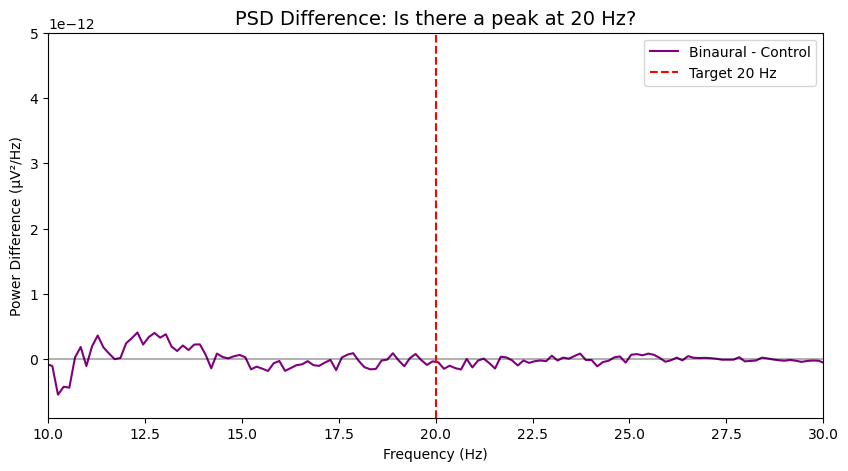

In [52]:

# 1. Extract the data from the PSD objects
psds1, freqs = obj1.get_data(return_freqs=True) # Control
psds2, _     = obj2.get_data(return_freqs=True) # Binaural

# 2. Calculate the mean across all channels
mean_psd1 = psds1.mean(axis=0)
mean_psd2 = psds2.mean(axis=0)

# 3. Calculate the Difference (Binaural - Control)
psd_diff = mean_psd2 - mean_psd1

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the difference line
ax.plot(freqs, psd_diff, color='purple', label='Binaural - Control')

# Add a reference line at zero
ax.axhline(0, color='black', linestyle='-', alpha=0.3)

# Highlight the 20 Hz Target
ax.axvline(20, color='red', linestyle='--', label='Target 20 Hz')

# Formatting
ax.set_title("PSD Difference: Is there a peak at 20 Hz?", fontsize=14)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Difference (µV²/Hz)")
ax.legend()

# OPTIONAL: Zoom in on the area of interest
ax.set_xlim(10, 30) 

plt.show()

## What about a more local ROI (jeg ved ikke hvilke endnu, det skal vi tale om)

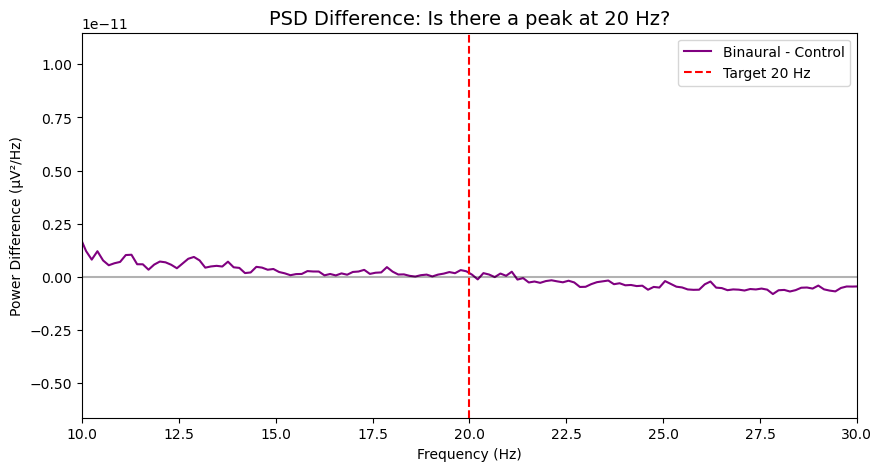

In [53]:
obj1 = res1_ROI["psd_obj"]
obj2 = res2_ROI["psd_obj"]



psds1, freqs = obj1.get_data(return_freqs=True) # Control
psds2, _     = obj2.get_data(return_freqs=True) # Binaural

# 2. Calculate the mean across all channels
mean_psd1 = psds1.mean(axis=0)
mean_psd2 = psds2.mean(axis=0)

# 3. Calculate the Difference (Binaural - Control)
psd_diff = mean_psd2 - mean_psd1

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the difference line
ax.plot(freqs, psd_diff, color='purple', label='Binaural - Control')

# Add a reference line at zero
ax.axhline(0, color='black', linestyle='-', alpha=0.3)

# Highlight the 20 Hz Target
ax.axvline(20, color='red', linestyle='--', label='Target 20 Hz')

# Formatting
ax.set_title("PSD Difference: Is there a peak at 20 Hz?", fontsize=14)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Difference (µV²/Hz)")
ax.legend()

# OPTIONAL: Zoom in on the area of interest
ax.set_xlim(10, 30) 

plt.show()

In [ ]:
g1_Park = ["AF7", "AF8", "TP7", "TP8"]
g2_Gonzalez = ["T7", "T8", "P8", "O2", "F8", "F7"]

In [58]:
import pandas as pd
import numpy as np

# 1. Define your Regions of Interest (ROIs)
rois = {
    'Frontal': [
        'Fp1', 'AF3', 'AF7', 'F3', 'F5', 'F7',  # Left Frontal
        'Fp2', 'AF4', 'AF8', 'F4', 'F6', 'F8'   # Right Frontal
    ],
    'Auditory': [
        'FT7', 'T7', 'TP7', 'FC5', 'C5', 'CP5', # Left Auditory
        'FT8', 'T8', 'TP8', 'FC6', 'C6', 'CP6', # Right Auditory
        'Fz', 'FCz', 'Cz'                       # Midline Vertex
    ],
    'Occipital_Visual': ['O1', 'O2', 'Oz', 'PO3', 'PO4', 'POz', 'PO7', 'PO8'],

    "Gonzalez" : ["T7", "T8", "P8", "O2", "F8", "F7"]
}

def extract_roi_power(clean_raw, participant_id, condition_name):
    sfreq = clean_raw.info['sfreq']
    segment_duration = 20.0  # 20-second windows
    total_duration = clean_raw.times[-1]
    n_segments = int(total_duration // segment_duration)
    
    rows = []
    
    for seg in range(n_segments):
        tmin = seg * segment_duration
        tmax = tmin + segment_duration
        
        # Crop out this 20-second slice of data
        seg_data = clean_raw.copy().crop(tmin=tmin, tmax=tmax, verbose=False)
        
        # Compute PSD
        psd_obj = seg_data.compute_psd(method='welch', fmin=18, fmax=22, n_fft=1024, verbose=False)
        psds, freqs = psd_obj.get_data(return_freqs=True)
        idx_20hz = np.argmin(np.abs(freqs - 20))
        
        # --- FIXED: CALCULATE THE GLOBAL BASELINE ---
        # Since psds ONLY contains valid brain channels now, we can safely average 
        # across all its rows without manually filtering out 'Status' or 'bads'
        global_20hz_power = psds[:, idx_20hz].mean()
        
        # Extract power for each ROI
        for roi_name, channels in rois.items():
            # FIXED: Find indices relative to the psd_obj channel order
            ch_indices = [psd_obj.ch_names.index(ch) for ch in channels if ch in psd_obj.ch_names]
            
            if ch_indices:
                # 1. Absolute power
                roi_abs_power = psds[ch_indices, idx_20hz].mean()
                
                # 2. Relative power (Normalized by the global baseline)
                roi_relative_power = roi_abs_power / global_20hz_power
                
                rows.append({
                    'Participant': participant_id,
                    'Condition': condition_name,
                    'Segment_ID': seg + 1,  # Tracks the chronological timeline chunks
                    'ROI': roi_name,
                    'abs_power': roi_abs_power,
                    'relative_power': roi_relative_power  
                })
            
    return pd.DataFrame(rows)

# Run the updated pipeline
df_cond1 = extract_roi_power(d_s1, participant_id='VJJ', condition_name='Binaural')
df_cond2 = extract_roi_power(d_s2, participant_id='VJJ', condition_name='Control')
data_long = pd.concat([df_cond1, df_cond2], ignore_index=True)





In [59]:
data_long.to_csv("eeg_binaural_power.csv", index=False)